In [14]:
import os
os.chdir('/Users/ahmadwajidarghand/spotify_project')

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


In [15]:
df = pd.read_csv('spotify_songs.csv')

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 100 rows × 8 columns


,name,artists,energy,key,mode,valence,tempo,duration_ms
0,God's Plan,Drake,0.449,7,1,0.357,77.169,198973
1,SAD!,XXXTENTACION,0.613,8,1,0.473,75.023,166606
2,rockstar (feat. 21 Savage),Post Malone,0.535,5,0,0.140,159.847,218147
3,Psycho (feat. Ty Dolla $ign),Post Malone,0.559,8,1,0.439,140.124,221440
4,In My Feelings,Drake,0.626,1,1,0.350,91.030,217925


In [3]:
import os
print(os.getcwd())

/Users/ahmadwajidarghand


In [4]:
import os

for root, dirs, files in os.walk('/Users/ahmadwajidarghand'):
    for file in files:
        if file.endswith('.csv') and 'spotify' in file.lower():
            print(os.path.join(root, file))

/Users/ahmadwajidarghand/spotify_project/spotify_songs.csv


In [5]:
os.chdir('/Users/ahmadwajidarghand/spotify_project')
print(os.getcwd())

/Users/ahmadwajidarghand/spotify_project


In [6]:
df = pd.read_csv('spotify_songs.csv')

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 100 rows × 8 columns


,name,artists,energy,key,mode,valence,tempo,duration_ms
0,God's Plan,Drake,0.449,7,1,0.357,77.169,198973
1,SAD!,XXXTENTACION,0.613,8,1,0.473,75.023,166606
2,rockstar (feat. 21 Savage),Post Malone,0.535,5,0,0.140,159.847,218147
3,Psycho (feat. Ty Dolla $ign),Post Malone,0.559,8,1,0.439,140.124,221440
4,In My Feelings,Drake,0.626,1,1,0.350,91.030,217925


In [7]:
# Check column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         100 non-null    object 
 1   artists      100 non-null    object 
 2   energy       100 non-null    float64
 3   key          100 non-null    int64  
 4   mode         100 non-null    int64  
 5   valence      100 non-null    float64
 6   tempo        100 non-null    float64
 7   duration_ms  100 non-null    int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 6.4+ KB


In [8]:
# Summary statistics
df.describe().round(2)

,energy,key,mode,valence,tempo,duration_ms
count,100.00,100.00,100.00,100.00,100.00,100.00
mean,0.66,5.33,0.59,0.48,119.90,205206.78
std,0.15,3.68,0.49,0.21,28.80,40007.89
min,0.30,0.00,0.00,0.08,64.93,95467.00
25%,0.56,1.75,0.00,0.34,95.73,184680.00
50%,0.68,5.00,1.00,0.47,120.12,205047.50
75%,0.77,8.25,1.00,0.64,140.02,221493.25
max,0.91,11.00,1.00,0.93,198.08,417920.00


In [9]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)

# Remove duplicates just in case
df = df.drop_duplicates()
print(f'\n✅ Clean dataset: {df.shape[0]} rows remaining')

Missing values per column:
name           0
artists        0
energy         0
key            0
mode           0
valence        0
tempo          0
duration_ms    0
dtype: int64

✅ Clean dataset: 100 rows remaining


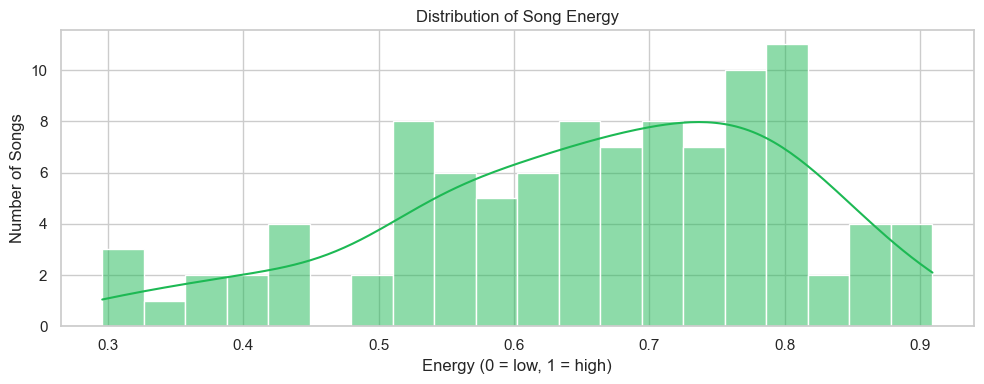

In [10]:
plt.figure(figsize=(10, 4))
sns.histplot(df['energy'], bins=20, color='#1DB954', kde=True)
plt.title('Distribution of Song Energy')
plt.xlabel('Energy (0 = low, 1 = high)')
plt.ylabel('Number of Songs')
plt.tight_layout()
plt.show()

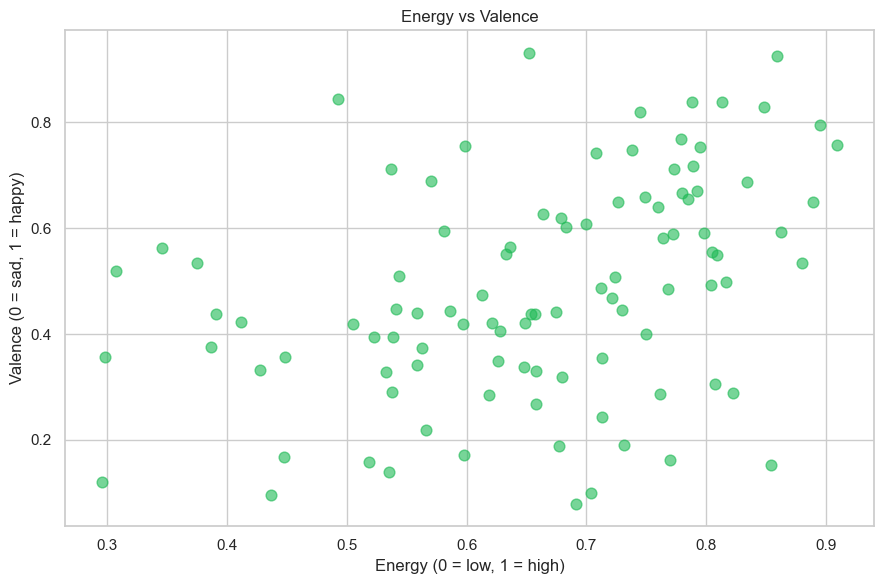

In [11]:
plt.figure(figsize=(9, 6))
plt.scatter(df['energy'], df['valence'], color='#1DB954', alpha=0.6, s=60)
plt.title('Energy vs Valence')
plt.xlabel('Energy (0 = low, 1 = high)')
plt.ylabel('Valence (0 = sad, 1 = happy)')
plt.tight_layout()
plt.show()

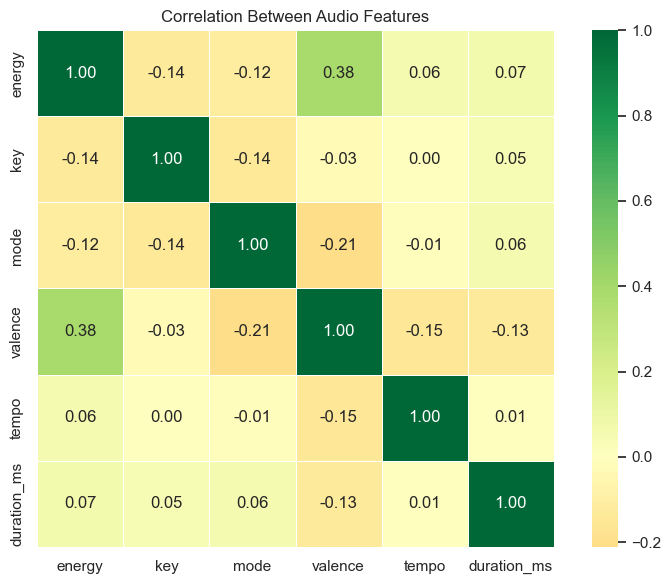

In [12]:
features = ['energy', 'key', 'mode', 'valence', 'tempo', 'duration_ms']

corr = df[features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Between Audio Features')
plt.tight_layout()
plt.show()

In [13]:
print('=== KEY FINDINGS ===')
print(f"Total songs analyzed: {len(df)}")
print(f"Average energy: {df['energy'].mean():.2f}")
print(f"Average valence (happiness): {df['valence'].mean():.2f}")
print(f"Average tempo: {df['tempo'].mean():.1f} BPM")
print(f"Most common mode: {'Major' if df['mode'].mode()[0] == 1 else 'Minor'}")

print('\n=== TOP 5 HIGHEST ENERGY SONGS ===')
top5 = df.nlargest(5, 'energy')[['name', 'artists', 'energy', 'valence']]
print(top5.to_string(index=False))

print('\n=== TOP 5 HAPPIEST SONGS (by valence) ===')
happy5 = df.nlargest(5, 'valence')[['name', 'artists', 'energy', 'valence']]
print(happy5.to_string(index=False))

=== KEY FINDINGS ===
Total songs analyzed: 100
Average energy: 0.66
Average valence (happiness): 0.48
Average tempo: 119.9 BPM
Most common mode: Major

=== TOP 5 HIGHEST ENERGY SONGS ===
                                       name       artists  energy  valence
                              Nice For What         Drake   0.909    0.757
1, 2, 3 (feat. Jason Derulo & De La Ghetto)   Sofia Reyes   0.895    0.794
                            ?chame La Culpa    Luis Fonsi   0.889    0.649
                                    FRIENDS    Marshmello   0.880    0.534
                   One Kiss (with Dua Lipa) Calvin Harris   0.862    0.592

=== TOP 5 HAPPIEST SONGS (by valence) ===
                                   name       artists  energy  valence
                           Shape of You    Ed Sheeran   0.652    0.931
        Finesse (Remix) [feat. Cardi B]    Bruno Mars   0.859    0.926
                                  Bella       Wolfine   0.493    0.844
D?jala que vuelva (feat. Manuel Turi